# Supplementary Analysis

## Setup

In [1]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr
import pandas as pd

from scipy.signal import sosfiltfilt, butter, sosfilt, welch
from scipy.stats import entropy, skew, kurtosis, pearsonr, spearmanr
from scipy.linalg import sqrtm
os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss
from scipy.signal import butter, sosfiltfilt

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.models.WGAN_v0 import WGAN_GP_V0
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

def generate_data(model, x, sub, pos, latent_dim=128, use_random_sub=False, apply_sub_layer=False, use_global_mean_std=False):
    B, T, C = x.shape
    l = len(x)
    x_gen = torch.zeros((B, T, C))
    bs = 128
    random_sub = keras.random.randint(sub.shape, 0, sub.max(), dtype=torch.int64)

    if use_random_sub:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()
            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    random_sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    else:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()

            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    # fill in the rest
    tr_sh = (x_gen.shape[0]//bs)*bs
    if tr_sh < B:
        res = B - tr_sh
        if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
        else:
            x_mean, x_std = x[-res:].mean(), x[-res:].std()
        x_gen[-res:] = model.generator((keras.random.normal((res, 128), mean=x_mean, stddev=x_std),
                                                sub[-res:].to('mps'),
                                                pos[-res:].to('mps'))).cpu().detach()
    
    # use subject layer in data generation
    if apply_sub_layer:
        print('applying the subject layer...')
        if use_random_sub:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), random_sub.to('mps')).cpu().detach()
        else:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), sub.to('mps')).cpu().detach()

    return x_gen

def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    if reverse_first:
        x = reverse_segmentation(x, n_subjects)
    else:
        x = x.permute(0, 2, 1)
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

def plot_time_domain(x, x_gen, time_dim, channels, ax, ch=0):
    x, x_gen = x[:, ch, :time_dim], x_gen[:, ch, :time_dim]
    real_data_avg = x.mean(0)
    fake_data_avg = x_gen.mean(0)
    ax.plot(fake_data_avg, label="Generated", color='orangered')
    ax.plot(real_data_avg, label="Real", color='navy', alpha=0.5)

    ax.fill_between(np.arange(time_dim),
                    real_data_avg - x.std(axis=0),
                    real_data_avg + x.std(axis=0),
                    alpha=0.4, color='navy')
    
    ax.fill_between(np.arange(time_dim),
            fake_data_avg - x_gen.std(axis=0),
            fake_data_avg + x_gen.std(axis=0),
            alpha=0.4, color='orangered')

    ax.set_title(f'Channel {channels[ch]}', fontsize=14, color='blue', loc='left')
    ax.set_xlim([0, time_dim])


def plot_psd_individual_subjects(reversed_x, channels, ax, n_sub_plotted=2, fmin=1, fmax=60, n_fft=512, color='blue'):
    psd, freq = mne.time_frequency.psd_array_welch(reversed_x[:n_sub_plotted], sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    psd = 10*np.log10(psd)
    for n in range(n_sub_plotted):
        for i, c in enumerate(range(len(channels))):
            psd_ = psd[n, c, :]
            ax[i//4, i%4].plot(freq, psd_, label=f'subject {n}', linewidth=2)
            ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
            ax[i//4, i%4].set_xlim([0.7, fmax])

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first'):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    return psd, psd_gen, freq

def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([mean, std, skewness, kurtosis_, rms], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

def aggregate_features(real_signal, gen_signal):
    # Extract features
    real_time_features = time_domain_features_multi_channel(real_signal)
    real_hjorth_features = hjorth_parameters_multi_channel(real_signal)
    real_spectral_features = spectral_features_multi_channel(real_signal)
    
    gen_time_features = time_domain_features_multi_channel(gen_signal)
    gen_hjorth_features = hjorth_parameters_multi_channel(gen_signal)
    gen_spectral_features = spectral_features_multi_channel(gen_signal)
    
    # Concatenate features
    real_features = np.concatenate([real_time_features, real_hjorth_features, real_spectral_features], axis=-1)
    gen_features = np.concatenate([gen_time_features, gen_hjorth_features, gen_spectral_features], axis=-1)
    
    # # Reshape to 2D for FID
    # real_features = real_features.reshape(real_features.shape[0], -1)  # Flatten across channels
    # gen_features = gen_features.reshape(gen_features.shape[0], -1)
    
    return real_features, gen_features

def compute_fid(x_features, y_features):
    # Mean and covariance
    mean1, cov1 = x_features.mean(axis=0), np.cov(x_features, rowvar=False)
    mean2, cov2 = y_features.mean(axis=0), np.cov(y_features, rowvar=False)
    # Mean difference
    mean_diff = np.sum((mean1 - mean2)**2)
    
    # Covariance square root
    covmean = sqrtm(cov1 @ cov2)
    
    # Numerical stability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # FID formula
    fid = mean_diff + np.trace(cov1 + cov2 - 2 * covmean)
    return fid

## DATA

In [2]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 5
EEG_DATA_PATH = 'data/LEMON_data/EC_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# PATHS
STAT_PATH = 'logs/5/20250605_7th.csv'
CHECKPOINTS_PATH = 'logs/5/20250605_7th_epoch_1280.model.keras'

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x = segment_data(x, TIME_DIM) # TODO
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])
pos = torch.tensor(xarray.ch_positions[None].repeat(x.shape[0], 0))
# data = {'x': x, 'sub': sub, 'pos': pos}

>>>>Corrected Mean: 2.130118715896519e-05, Std: 6.870344713837771e-05, Max: 0.0033820224248497887, Min: -0.00045107680079173166
>>>>Scaled Mean: 0.007879140460674436, Std: 0.9719220134947318, Max: 32.71363836318784, Min: -4.488456419257331
>>>>Normalized Mean: 1.8947806286936006e-16, Std: 0.9999999999999999, Max: 14.326581977664722, Min: -5.50498774788029
>>>>Clamped Mean: 1.8947806286936006e-16, Std: 0.9999999999999999, Max: 14.326581977664722, Min: -5.50498774788029
Power of components removed by DSS: 0.02


### Fake Data

In [ ]:
# FAKE DATA
model = WGAN_GP_V0(time_dim=512, feature_dim=len(CHANNELS),
                   latent_dim=LATENT_DIM, n_subjects=202,
                   use_sublayer_generator=True,
                   use_sublayer_critic=True,
                   use_channel_merger_g=False,
                   use_channel_merger_c=False,
                   interpolation='bilinear')

# load model and history
model.load_weights(CHECKPOINTS_PATH)

with torch.no_grad():
    x_gen = generate_data(model, x, sub, pos, latent_dim=LATENT_DIM, apply_sub_layer=False, use_random_sub=False,
                          use_global_mean_std=True)

In [ ]:
_, ax = plt.subplots(2, 4, figsize=(20, 8))
plot_psd_multi_channel(x, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True)
plot_psd_multi_channel(x_gen, CHANNELS, ax, n_subjects=N_SUBJECTS, color='red', reverse_first=True)

## Metrics for features similarity
### frequency domain

In [ ]:
real_psd, fake_psd, freqs = calculate_psd_different_methods(x, x_gen, 202, method='reorder_first')

# correlation between real and fake psd
corr, _ = pearsonr(real_psd.mean(0), fake_psd.mean(0), axis=1)
r_s, _ = spearmanr(psd.mean(0), psd_gen.mean(0), axis=1)
print(r_s.mean(), corr.mean())

0.9920835373835738 0.9650752518031476


### Statistical features of the timeseries

In [ ]:
fids = {}
for j, func in enumerate([hjorth_parameters_multi_channel,
                          spectral_features_multi_channel,
                          time_domain_features_multi_channel]):

    real_f = func(x.permute(0, 2, 1).cpu().detach().numpy())
    gen_f = func(x_gen.permute(0, 2, 1).cpu().detach().numpy())
    from scipy.stats import zscore

    real_f = zscore(real_f, axis=0)
    gen_f = zscore(gen_f, axis=0)
    print(f'Correlation on {func.__name__[:-14]}: {pearsonr(real_f, gen_f, axis=-1)[0].mean()}')  # TODO: consider standardizing the features before computing FID

corr_ts, _ = pearsonr(x_gen.mean(0), x.mean(0), axis=0)
print(f'correlation of averaged segments: {corr_ts.mean()}')

In [ ]:
# fig, ax = plt.subplots(2, 4, figsize=(20, 8))
# # plot_psd_individual_subjects(reverse_segmentation(x_gen, N_SUBJECTS).numpy(), CHANNELS, ax, n_sub_plotted=5)
# plot_psd_individual_subjects(reverse_segmentation(x, N_SUBJECTS).numpy(), CHANNELS, ax, n_sub_plotted=5)


fig, ax = plt.subplots(8, 1, figsize=(20, 16))
for i, ch in enumerate(range(len(CHANNELS))):
        plot_time_domain(reverse_segmentation(x, N_SUBJECTS), reverse_segmentation(x_gen, N_SUBJECTS), 4096, CHANNELS, ax[i], ch)

plt.legend()
plt.show()


## Fréchet Distance between features

In [ ]:
def creat_df4FD(all_wd):
    all_wd_df = pd.DataFrame(all_wd, index=[0])
    all_wd_df = all_wd_df.melt(var_name='name', value_name='WD')
    all_wd_df[['channel', 'feature']] = all_wd_df['name'].apply(lambda x: x.split('_')).apply(pd.Series)
    all_wd_df.drop('name', axis=1, inplace=True)
    all_wd_df = all_wd_df.pivot(columns='feature', values='WD', index=['channel'])
    
    all_wd_df.reset_index(inplace=True)
    all_wd_df.set_index(['channel'], inplace=True)
    return all_wd_df

In [19]:
f_names = ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'activity', 'mobility', 'complexity',
           'delta', 'theta', 'alpha', 'beta', 'gamma', 'entropy']

all_wd = {}
bs = 128
reverse = False

if reverse:
    real_f, fake_f = aggregate_features(reverse_segmentation(x, N_SUBJECTS).cpu().detach().numpy(),
                                        reverse_segmentation(x_gen, N_SUBJECTS).cpu().detach().numpy()) 

else:
    real_f, fake_f = aggregate_features(x.permute(0, 2, 1).cpu().detach().numpy(),
                                        x_gen.permute(0, 2, 1).cpu().detach().numpy())

for ch in range(0, len(CHANNELS), 2):
    for fn in range(len(f_names)):
        all_wd[f'{CHANNELS[ch]}_{f_names[fn]}'] = compute_fid(real_f[:, [ch, ch+1], fn],
                                                              fake_f[:, [ch, ch+1], fn])

if reverse:
    all_wd_df_r = creat_df4FD(all_wd)
else:
    all_wd_df = creat_df4FD(all_wd)

In [ ]:
fig, axes = plt.subplots(8, 14, figsize=(40, 20))
brain_areas = ['occipital', 'parietal', 'central', 'frontal']
for ch_idx in range(len(CHANNELS)):
    for fn in range(len(f_names)):
        sns.histplot(real_f[:, ch_idx, fn], color='blue', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='real', stat='density')
        sns.histplot(fake_f[:, ch_idx, fn], color='red', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='fake', stat='density')
        axes[ch_idx, fn].legend()
        if ch_idx == 0:
            axes[ch_idx, fn].set_title(f_names[fn], fontsize=18, color='blue')
        if fn == 0:
            axes[ch_idx, fn].set_ylabel(CHANNELS[ch_idx], fontsize=18, color='blue')
        else:
            axes[ch_idx, fn].set_ylabel('')
fig.suptitle('Feature Distribution Comparison: Real vs. Fake (Final Epoch)', color='blue', fontsize=20)
plt.show()

## Functional Connectivity

In [ ]:
def plot_connectivity(conn_real, conn_fake):
    _, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(conn_real, vmin=0, vmax=1.4, ax=ax[0], annot=True)
    ax[0].set_title('Generated data')
    sns.heatmap(conn_fake, vmin=0, vmax=1.4, ax=ax[1], annot=True)
    ax[1].set_title('Real data')

    plt.tight_layout()

In [35]:
from mne_connectivity import spectral_connectivity_time

x_real_conn = x.flatten(0, 1).reshape(150, 2048, 8).permute(0, 2, 1).numpy()
x_fake_conn = x_gen.flatten(0, 1).reshape(150, 2048, 8).permute(0, 2, 1).numpy()

cons_real = spectral_connectivity_time(x_real_conn, freqs=np.arange(1, 20, 2), method='coh', sfreq=128, n_jobs=1, fmin=1, fmax=5, verbose=0, average=True)
cons_fake = spectral_connectivity_time(x_fake_conn, freqs=np.arange(1, 20, 2), method='coh', sfreq=128, n_jobs=1, fmin=1, fmax=5, verbose=0, average=True)

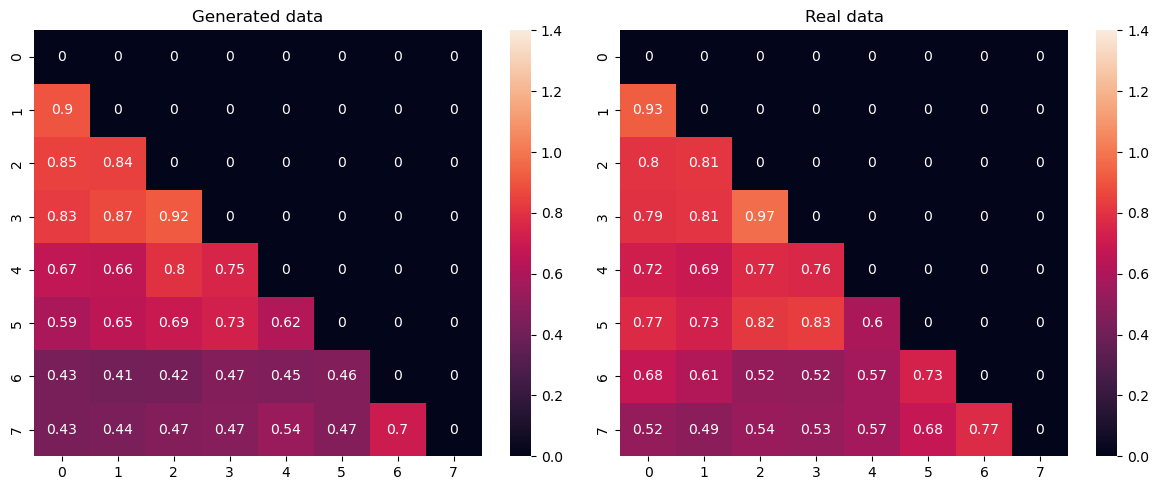

In [ ]:
coh_real = cons_real.get_data(output='dense')[..., 0]
coh_fake = cons_fake.get_data(output='dense')[..., 0]

plot_connectivity(coh_real, coh_fake)

### Correlation

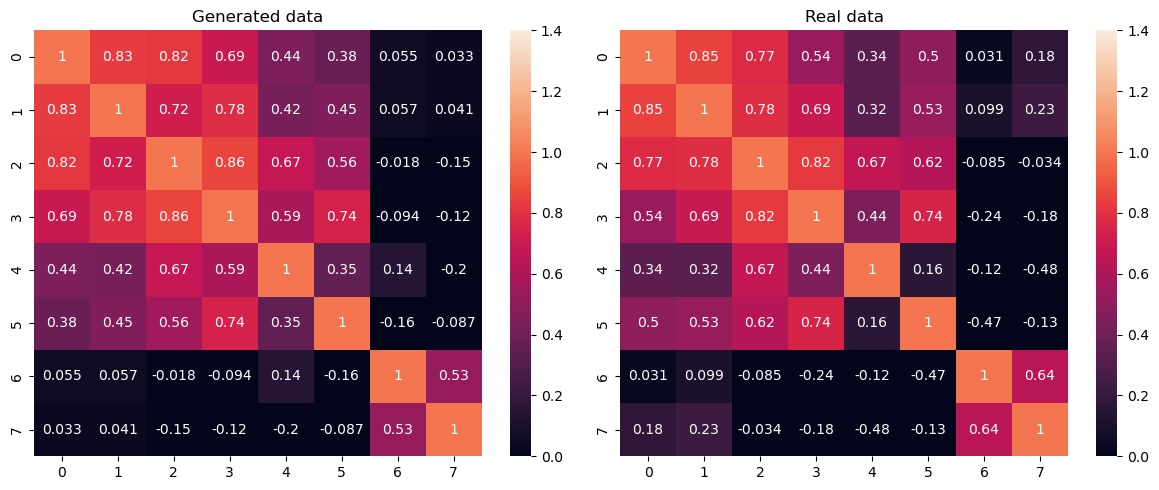

In [45]:
import numpy as np

# data: (n_channels, n_times)
corr_real = np.corrcoef(x.flatten(0, 1).T.numpy()) 
corr_fake = np.corrcoef(x_gen.flatten(0, 1).T.numpy()) 

plot_connectivity(corr_real, corr_fake)